<a href="https://colab.research.google.com/github/Janeyy-A/PINN_KAN-PIKAN/blob/main/KANV3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  KAN -- 2D Advection-Diffusion PDE  (focus: y = second dim)
  Grid    : 21x21 spatial,  Nt=41 time-steps
  Dx=0.050  Dy=0.050  Dt=0.02500
  cx=0.5,  cy=0.5,  D=0.01
  IC: u(x,y,0) = x+y  |  BC: u=0 (Dirichlet, constant=0)
  Plots will be saved to: /content/kan_outputs

Solving PDE numerically ...
  PDE solved in 0.00s  (41 snapshots)

  Dataset : 18,081 samples  |  train 15,368 / val 2,713
  Device  : cuda
  KAN     : [3, 12, 12, 1]  grid=5  order=3  params=1,776

 Epoch |   Train Loss |      Val MSE |    |DLoss| |        LR |    Wall
--------------------------------------------------------------------
     1 |     0.179582 |     0.103350 |        inf |  3.00e-03 |   0.0s
    25 |     0.000664 |     0.000777 |   4.82e-05 |  3.00e-03 |   8.1s
    50 |     0.000295 |     0.000315 |   3.74e-05 |  3.00e-03 |  16.0s
    75 |     0.000134 |     0.000301 |   1.04e-04 |  3.00e-03 |  24.6s
   100 |     0.000502 |     0.000226 |   5.98e-04 |  3.00e-03 |  32.9s
   125 |     0.000053 |     0.0000

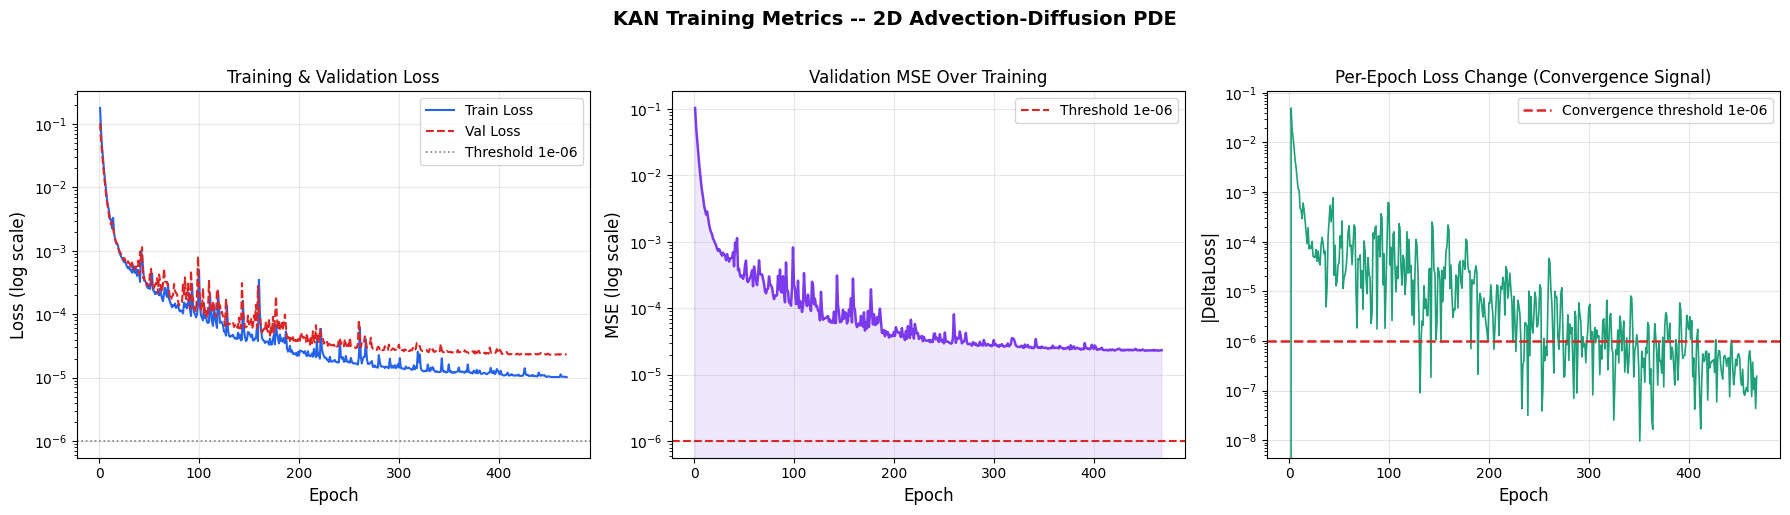

  -> saved 01_training_metrics.png  (/content/kan_outputs/01_training_metrics.png)


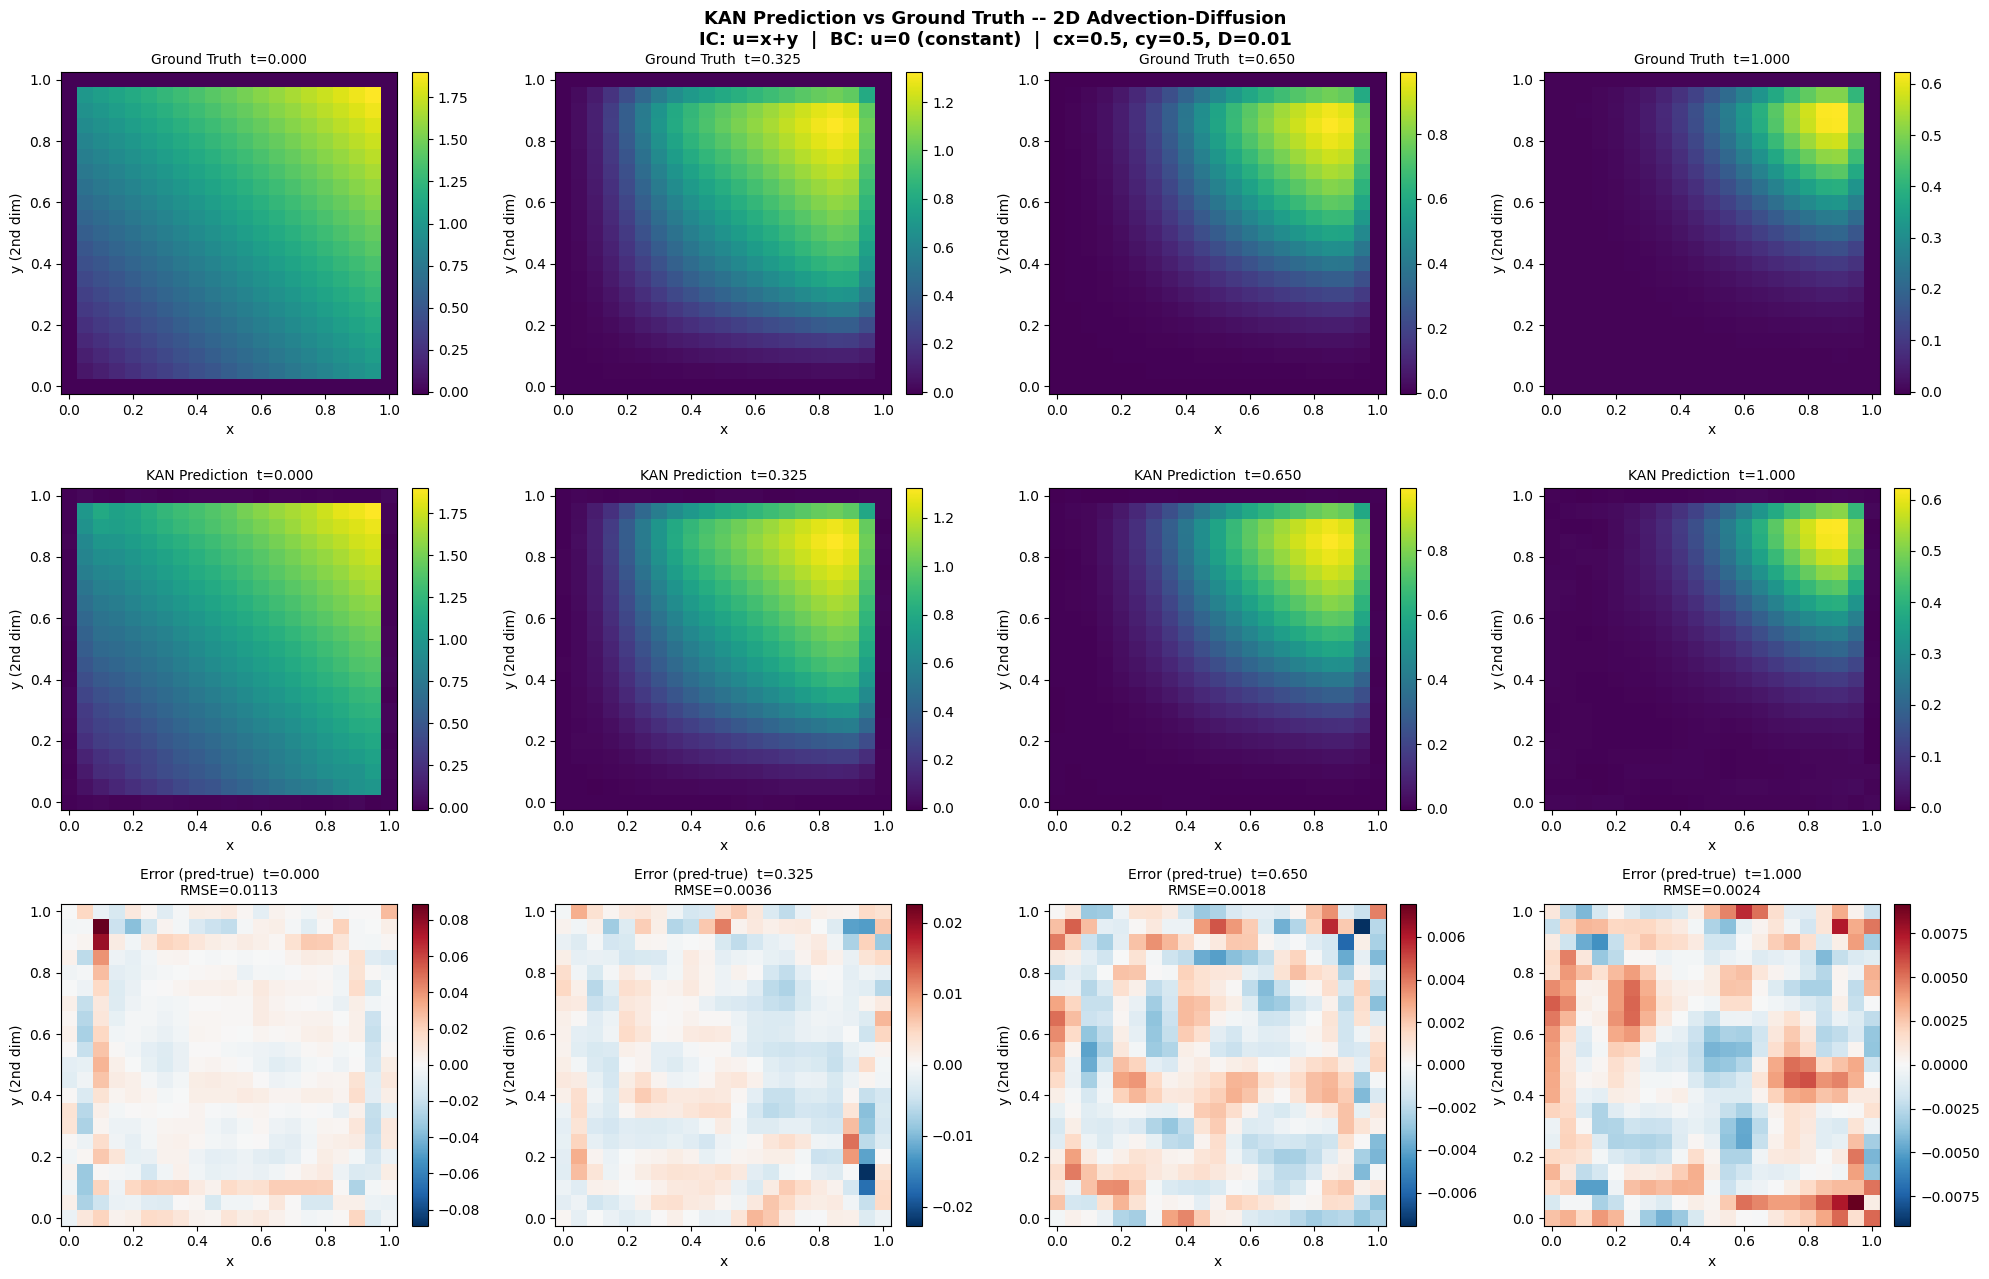

  -> saved 02_snapshot_comparison.png  (/content/kan_outputs/02_snapshot_comparison.png)


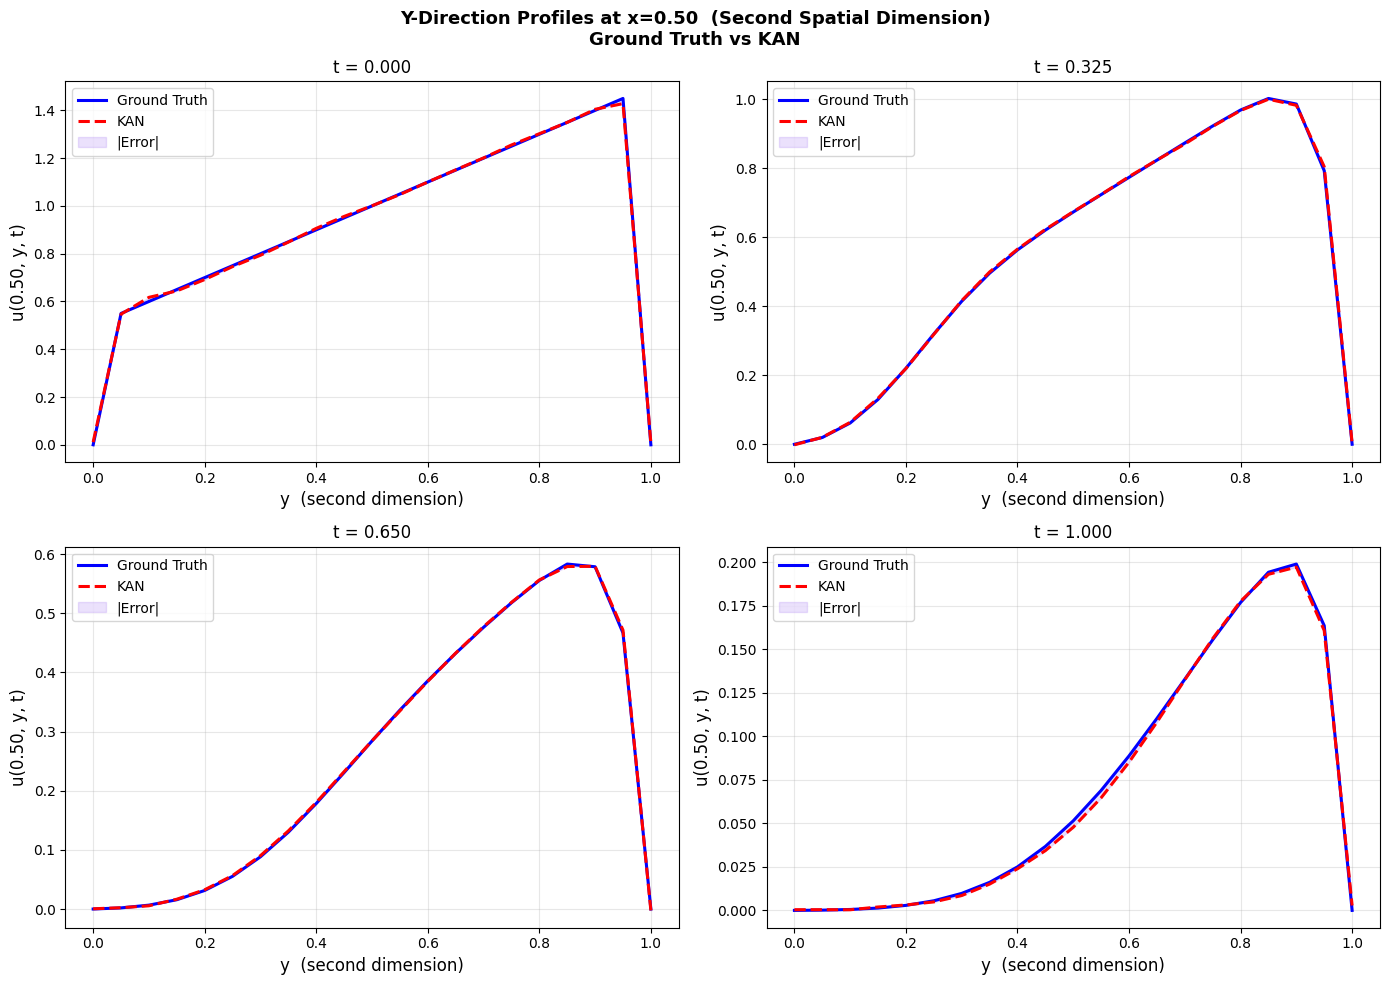

  -> saved 03_y_profiles_second_dim.png  (/content/kan_outputs/03_y_profiles_second_dim.png)


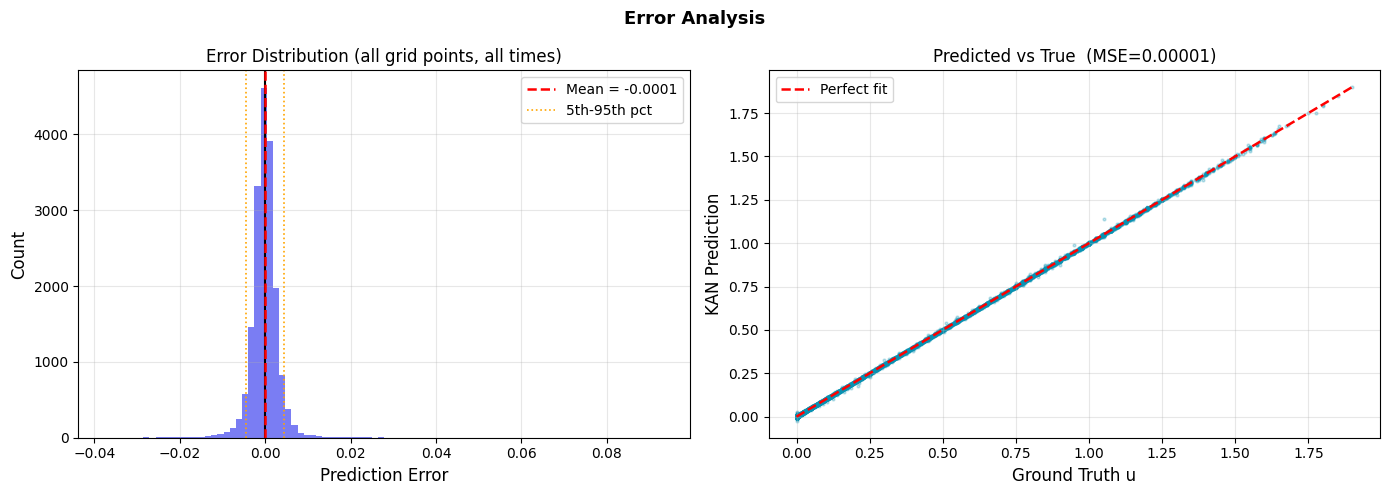

  -> saved 04_error_analysis.png  (/content/kan_outputs/04_error_analysis.png)


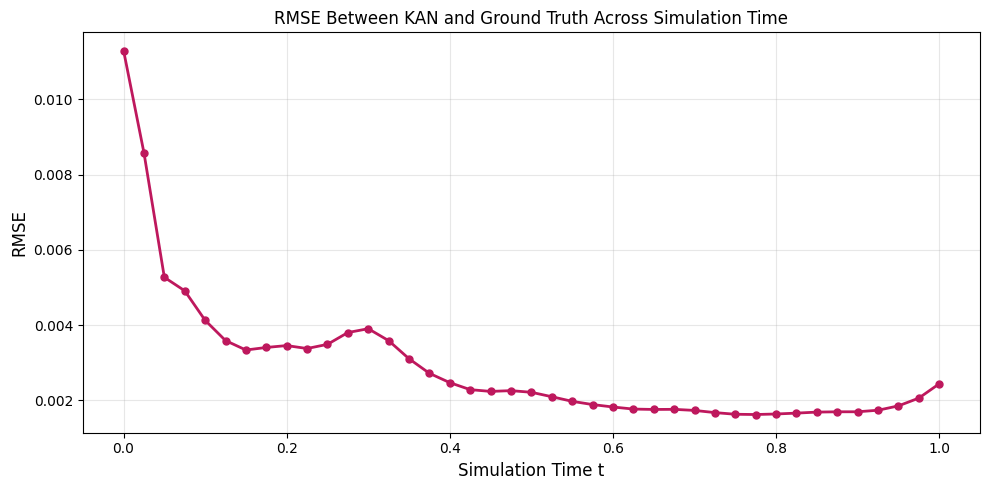

  -> saved 05_rmse_over_time.png  (/content/kan_outputs/05_rmse_over_time.png)


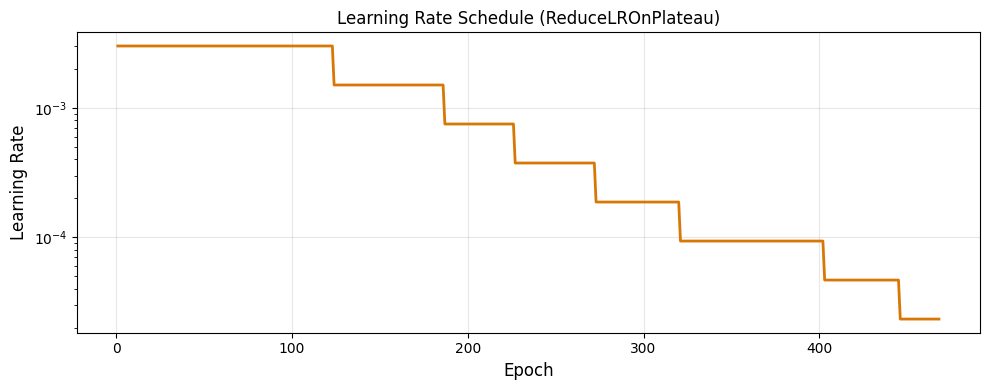

  -> saved 06_lr_schedule.png  (/content/kan_outputs/06_lr_schedule.png)


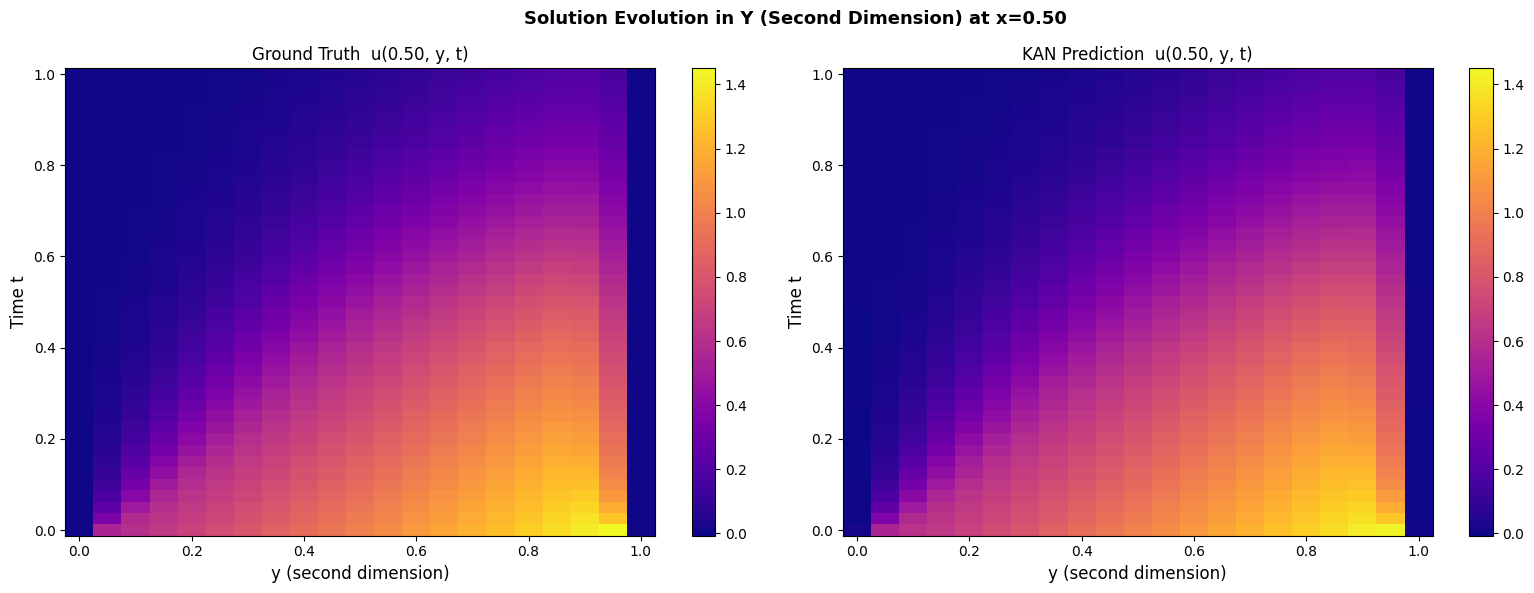

  -> saved 07_y_time_heatmap.png  (/content/kan_outputs/07_y_time_heatmap.png)
  -> saved kan_model.pt  (/content/kan_outputs/kan_model.pt)

  FINAL SUMMARY
  PDE              : 2D Advection-Diffusion, y = second dimension
  IC               : u(x,y,0) = x + y
  BC               : u = 0 on all boundaries (Dirichlet, const=0)
  cx=0.5,  cy=0.5,  D=0.01
  Grid             : Dx=0.05, Dy=0.05 -> 21x21 nodes
  KAN architecture : [3, 12, 12, 1]
  B-spline         : grid_size=5, order=3
  Total params     : 1,776
  Stop reason      : convergence
  Epochs run       : 468
  Best val MSE     : 0.000023
  Full MSE         : 0.000012
  RMSE             : 0.003469
  Rel. L1 error    : 0.62 %
  Training time    : 153.2s (2.6 min)
  All files saved  : /content/kan_outputs/


In [2]:
#!/usr/bin/env python3
"""
Kolmogorov-Arnold Network (KAN) -- 2D Advection-Diffusion PDE
=============================================================
PDE    :  du/dt + cx*du/dx + cy*du/dy = D*(d2u/dx2 + d2u/dy2)
Domain :  x,y in [0,1],  t in [0, 1]
IC     :  u(x, y, 0) = x + y
BC     :  u = 0 on all boundaries  (homogeneous Dirichlet, constant = 0)
Focus  :  Second spatial dimension  (y-direction)

Convergence stops when |DeltaLoss| < 1e-4 for PATIENCE consecutive epochs.
Hard wall-clock limit: 1 hour.

Colab-ready: all plots display inline AND are saved to /content/kan_outputs/
"""

import os, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# ── Colab-compatible matplotlib setup ──────────────────────────────────────────
# Do NOT call matplotlib.use("Agg") here — that suppresses inline display.
# The default Colab backend (inline) handles both show() and savefig() correctly.
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# ── Output directory (Colab-native path) ───────────────────────────────────────
OUT_DIR = "/content/kan_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

def save_and_show(filename):
    """Save figure to disk AND display it inline in the notebook."""
    fpath = os.path.join(OUT_DIR, filename)
    plt.savefig(fpath, dpi=150, bbox_inches="tight")
    plt.show()          # renders inline in Colab cell output
    plt.close()
    print(f"  -> saved {filename}  ({fpath})")

# ══════════════════════════════════════════════════════════════════════════════
# 1.  Vectorized KAN (fully batched B-spline activations)
# ══════════════════════════════════════════════════════════════════════════════

class VKANLayer(nn.Module):
    """
    Vectorized KAN layer: R^{in_dim} -> R^{out_dim}.
    All B-spline evaluations are batched via einsum — no Python loops at runtime.
    """
    def __init__(self, in_dim, out_dim, grid_size=5, spline_order=3,
                 grid_lo=-1.0, grid_hi=1.0):
        super().__init__()
        self.in_dim  = in_dim
        self.out_dim = out_dim
        self.k       = spline_order
        n_basis      = grid_size + spline_order   # number of B-spline coefficients

        # Learnable spline coefficients: (in_dim, out_dim, n_basis)
        self.coeff = nn.Parameter(torch.zeros(in_dim, out_dim, n_basis))
        nn.init.normal_(self.coeff, std=0.1)

        # Per-edge residual (SiLU) scale: (in_dim, out_dim)
        self.res_w = nn.Parameter(torch.zeros(in_dim, out_dim))

        # Knot vector (shared across input dims, stored as buffer — not trained)
        h     = (grid_hi - grid_lo) / grid_size
        knots = torch.linspace(
            grid_lo - spline_order * h,
            grid_hi + spline_order * h,
            grid_size + 2 * spline_order + 1
        )
        self.register_buffer("knots", knots)

    def _basis(self, x):
        """
        Cox-de Boor B-spline basis recursion, fully vectorized.
        x      : (batch, in_dim)
        returns: (batch, in_dim, n_basis)
        """
        k  = self.k
        t  = self.knots          # (n_knots,)
        n  = len(t) - k - 1     # n_basis

        xv = x.unsqueeze(-1)    # (batch, in_dim, 1)
        tv = t.view(1, 1, -1)   # (1,     1,      n_knots)

        # k=0 step: indicator basis
        B = ((xv >= tv[:, :, :-1]) & (xv < tv[:, :, 1:])).float()

        for r in range(1, k + 1):
            tL  = tv[:, :, :-(r + 1)];  tR  = tv[:, :, r:-1]
            dL  = (tR  - tL ).clamp(min=1e-8)
            tL2 = tv[:, :, 1:-r];       tR2 = tv[:, :, r + 1:]
            dR  = (tR2 - tL2).clamp(min=1e-8)
            B   = ((xv - tL) / dL) * B[:, :, :-1] + \
                  ((tR2 - xv) / dR) * B[:, :, 1:]

        return B[:, :, :n]   # (batch, in_dim, n_basis)

    def forward(self, x):
        # x: (batch, in_dim)
        B      = self._basis(x)
        spline = torch.einsum('bin,ion->bio', B, self.coeff)   # spline contribution
        res    = torch.einsum('bi,io->bio', F.silu(x), self.res_w)   # SiLU residual
        return (spline + 0.1 * res).sum(dim=1)   # (batch, out_dim)


class KAN(nn.Module):
    """Stack of VKANLayer with LayerNorm between hidden layers."""
    def __init__(self, widths, grid_size=5, spline_order=3):
        super().__init__()
        layers, norms = [], []
        for i in range(len(widths) - 1):
            layers.append(VKANLayer(widths[i], widths[i+1], grid_size, spline_order))
            if i < len(widths) - 2:
                norms.append(nn.LayerNorm(widths[i+1]))
        self.layers = nn.ModuleList(layers)
        self.norms  = nn.ModuleList(norms)

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.norms):
                x = self.norms[i](x)
        return x


# ══════════════════════════════════════════════════════════════════════════════
# 2.  PDE Parameters & Grid
# ══════════════════════════════════════════════════════════════════════════════
CX = 0.5      # advection speed  x
CY = 0.5      # advection speed  y  <-- SECOND SPATIAL DIMENSION
D  = 0.01     # diffusion coefficient
T  = 1.0      # total simulation time

DX = 0.05     # spatial step  Dx
DY = 0.05     # spatial step  Dy  (second spatial dimension)

# Stable time step: minimum of CFL and diffusion stability criteria
dt_cfl  = 0.4 * min(DX, DY) / max(CX, CY)
dt_diff = 0.4 * min(DX, DY)**2 / (4.0 * D)
DT      = min(dt_cfl, dt_diff)

Nx = int(round(1.0 / DX)) + 1
Ny = int(round(1.0 / DY)) + 1
Nt = int(round(T  / DT )) + 1

x_grid = np.linspace(0.0, 1.0, Nx)
y_grid = np.linspace(0.0, 1.0, Ny)   # second spatial dimension
XX, YY = np.meshgrid(x_grid, y_grid, indexing="ij")

print("=" * 65)
print("  KAN -- 2D Advection-Diffusion PDE  (focus: y = second dim)")
print("=" * 65)
print(f"  Grid    : {Nx}x{Ny} spatial,  Nt={Nt} time-steps")
print(f"  Dx={DX:.3f}  Dy={DY:.3f}  Dt={DT:.5f}")
print(f"  cx={CX},  cy={CY},  D={D}")
print(f"  IC: u(x,y,0) = x+y  |  BC: u=0 (Dirichlet, constant=0)")
print(f"  Plots will be saved to: {OUT_DIR}")
print("=" * 65)

# ══════════════════════════════════════════════════════════════════════════════
# 3.  Numerical PDE Solver  (upwind advection + central diffusion, explicit)
# ══════════════════════════════════════════════════════════════════════════════
N_SNAPS    = 40
save_every = max(1, Nt // N_SNAPS)

u = (XX + YY).astype(np.float64)
u[0,:] = u[-1,:] = u[:,0] = u[:,-1] = 0.0   # enforce BC on IC
snap_t, snap_U = [0.0], [u.copy()]

print("\nSolving PDE numerically ...", flush=True)
t0_pde = time.time()

for n in range(1, Nt):
    adv_x = CX * (u[1:-1,1:-1] - u[:-2,1:-1]) / DX    # upwind in x
    adv_y = CY * (u[1:-1,1:-1] - u[1:-1,:-2]) / DY    # upwind in y (2nd dim)
    lap_x = (u[2:,1:-1] - 2*u[1:-1,1:-1] + u[:-2,1:-1]) / DX**2
    lap_y = (u[1:-1,2:] - 2*u[1:-1,1:-1] + u[1:-1,:-2]) / DY**2

    u_new = u.copy()
    u_new[1:-1,1:-1] = u[1:-1,1:-1] + DT * (
        -adv_x - adv_y + D * (lap_x + lap_y)
    )
    u_new[0,:] = u_new[-1,:] = u_new[:,0] = u_new[:,-1] = 0.0
    u = u_new

    if (n % save_every == 0) or (n == Nt - 1):
        snap_t.append(n * DT)
        snap_U.append(u.copy())

snap_t = np.array(snap_t)
snap_U = np.array(snap_U)    # (n_snaps, Nx, Ny)
print(f"  PDE solved in {time.time()-t0_pde:.2f}s  ({len(snap_t)} snapshots)")

# ══════════════════════════════════════════════════════════════════════════════
# 4.  Dataset  (x, y, t) -> u
# ══════════════════════════════════════════════════════════════════════════════
xi_m, yj_m = np.meshgrid(x_grid, y_grid, indexing="ij")

inp_list, tgt_list = [], []
for k, tk in enumerate(snap_t):
    t_plane = np.full((Nx, Ny), tk, dtype=np.float32)
    inp_list.append(
        np.stack([xi_m, yj_m, t_plane], axis=-1).astype(np.float32).reshape(-1, 3)
    )
    tgt_list.append(snap_U[k].astype(np.float32).ravel())

inputs  = np.concatenate(inp_list, axis=0)   # (N, 3)
targets = np.concatenate(tgt_list, axis=0)   # (N,)

# Normalise inputs to [-1, 1]
in_min   = inputs.min(0); in_max = inputs.max(0)
inputs_n = 2.0 * (inputs - in_min) / (in_max - in_min + 1e-8) - 1.0

N     = len(inputs_n)
rng   = np.random.default_rng(42)
idx   = rng.permutation(N)
split = int(0.85 * N)
tr, va = idx[:split], idx[split:]

X_tr = torch.from_numpy(inputs_n[tr])
y_tr = torch.from_numpy(targets[tr]).unsqueeze(1)
X_va = torch.from_numpy(inputs_n[va])
y_va = torch.from_numpy(targets[va]).unsqueeze(1)

BATCH        = 512
train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_va, y_va), batch_size=BATCH * 8)

print(f"\n  Dataset : {N:,} samples  |  train {len(tr):,} / val {len(va):,}")

# ══════════════════════════════════════════════════════════════════════════════
# 5.  KAN Model & Optimizer
# ══════════════════════════════════════════════════════════════════════════════
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"  Device  : {device}")

WIDTHS     = [3, 12, 12, 1]
GRID_SIZE  = 5
SPLINE_ORD = 3

model    = KAN(WIDTHS, GRID_SIZE, SPLINE_ORD).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"  KAN     : {WIDTHS}  grid={GRID_SIZE}  order={SPLINE_ORD}  "
      f"params={n_params:,}")

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=15, factor=0.5, min_lr=5e-6
)
criterion = nn.MSELoss()

# ══════════════════════════════════════════════════════════════════════════════
# 6.  Training Loop
# ══════════════════════════════════════════════════════════════════════════════
MAX_WALL   = 3600.0   # hard 1-hour limit
THRESHOLD  = 1e-6     # convergence threshold on |DeltaLoss|
PATIENCE   = 25       # consecutive epochs below threshold -> stop
MAX_EPOCHS = 3000

train_losses, val_losses, lr_history = [], [], []
best_val, best_state = float("inf"), None
no_improve  = 0
stop_reason = "max_epochs"
prev_val    = float("inf")
wall_start  = time.time()

print(f"\n{'Epoch':>6} | {'Train Loss':>12} | {'Val MSE':>12} | "
      f"{'|DLoss|':>10} | {'LR':>9} | {'Wall':>7}")
print("-" * 68)

for epoch in range(1, MAX_EPOCHS + 1):
    elapsed = time.time() - wall_start
    if elapsed >= MAX_WALL:
        stop_reason = "time_limit"; break

    # ---- Train --------------------------------------------------------
    model.train()
    t_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        t_loss += loss.item() * xb.size(0)
    t_loss /= len(X_tr)

    # ---- Validate -----------------------------------------------------
    model.eval()
    v_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            v_loss += criterion(model(xb), yb).item() * xb.size(0)
    v_loss /= len(X_va)

    scheduler.step(v_loss)
    cur_lr = optimizer.param_groups[0]["lr"]

    train_losses.append(t_loss)
    val_losses.append(v_loss)
    lr_history.append(cur_lr)

    if v_loss < best_val:
        best_val   = v_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    delta = abs(prev_val - v_loss)
    if epoch % 25 == 0 or epoch == 1:
        print(f"{epoch:>6} | {t_loss:>12.6f} | {v_loss:>12.6f} | "
              f"{delta:>10.2e} | {cur_lr:>9.2e} | {elapsed:>5.1f}s")

    # ---- Convergence check --------------------------------------------
    if epoch > 30:
        no_improve = no_improve + 1 if delta < THRESHOLD else 0
        if no_improve >= PATIENCE:
            stop_reason = "convergence"
            print(f"\n  Converged at epoch {epoch}! "
                  f"|DLoss|={delta:.2e} < {THRESHOLD:.0e} "
                  f"for {PATIENCE} consecutive epochs")
            break

    prev_val = v_loss

# Restore best weights
if best_state:
    model.load_state_dict(best_state)
    model.to(device)

total_time  = time.time() - wall_start
final_epoch = len(train_losses)

print("\n" + "=" * 65)
print(f"  Stop reason   : {stop_reason}")
print(f"  Epochs run    : {final_epoch}")
print(f"  Best val MSE  : {best_val:.6f}")
print(f"  Training time : {total_time:.1f}s  ({total_time/60:.1f} min)")
print("=" * 65)

# ══════════════════════════════════════════════════════════════════════════════
# 7.  Full Predictions
# ══════════════════════════════════════════════════════════════════════════════
model.eval()
CHUNK      = 4096
u_pred_all = []
X_all_t    = torch.from_numpy(inputs_n).to(device)

with torch.no_grad():
    for i in range(0, len(X_all_t), CHUNK):
        u_pred_all.append(model(X_all_t[i:i+CHUNK]).cpu().numpy().ravel())

u_pred_all = np.concatenate(u_pred_all)
u_true_all = targets

mse_full = float(np.mean((u_pred_all - u_true_all)**2))
rmse_all = float(np.sqrt(mse_full))
rel_err  = float(
    np.mean(np.abs(u_pred_all - u_true_all)) / (np.mean(np.abs(u_true_all)) + 1e-12)
)

print(f"\n  Full-dataset MSE  : {mse_full:.6f}")
print(f"  RMSE              : {rmse_all:.6f}")
print(f"  Relative L1 error : {rel_err*100:.2f} %")

U_pred_snaps = u_pred_all.reshape(len(snap_t), Nx, Ny)
U_true_snaps = u_true_all.reshape(len(snap_t), Nx, Ny)
snap_idxs    = np.linspace(0, len(snap_t) - 1, 4, dtype=int)
ix_mid       = Nx // 2   # x ≈ 0.5 (used throughout for y-profile plots)
ep_a         = np.arange(1, final_epoch + 1)
FS           = 12

print(f"\n{'='*65}")
print("  Generating plots (displayed inline + saved to disk) ...")
print(f"{'='*65}\n")

# ══════════════════════════════════════════════════════════════════════════════
# 8.  Plot 1 — Training Loss | Validation MSE | Convergence Signal
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("KAN Training Metrics -- 2D Advection-Diffusion PDE",
             fontsize=14, fontweight="bold", y=1.02)

ax = axes[0]
ax.semilogy(ep_a, train_losses, lw=1.5, color="#2563EB", label="Train Loss")
ax.semilogy(ep_a, val_losses,   lw=1.5, color="#DC2626", ls="--", label="Val Loss")
ax.axhline(THRESHOLD, color="gray", ls=":", lw=1.2, label=f"Threshold {THRESHOLD:.0e}")
ax.set_xlabel("Epoch", fontsize=FS); ax.set_ylabel("Loss (log scale)", fontsize=FS)
ax.set_title("Training & Validation Loss", fontsize=FS)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogy(ep_a, val_losses, lw=1.8, color="#7C3AED")
ax.fill_between(ep_a, val_losses, alpha=0.12, color="#7C3AED")
ax.axhline(THRESHOLD, color="#DC2626", ls="--", lw=1.5,
           label=f"Threshold {THRESHOLD:.0e}")
ax.set_xlabel("Epoch", fontsize=FS); ax.set_ylabel("MSE (log scale)", fontsize=FS)
ax.set_title("Validation MSE Over Training", fontsize=FS)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

ax = axes[2]
delta_arr = np.abs(np.diff(val_losses, prepend=val_losses[0]))
ax.semilogy(ep_a, delta_arr, lw=1.2, color="#059669", alpha=0.9)
ax.axhline(THRESHOLD, color="#DC2626", ls="--", lw=1.8,
           label=f"Convergence threshold {THRESHOLD:.0e}")
ax.set_xlabel("Epoch", fontsize=FS); ax.set_ylabel("|DeltaLoss|", fontsize=FS)
ax.set_title("Per-Epoch Loss Change (Convergence Signal)", fontsize=FS)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.tight_layout()
save_and_show("01_training_metrics.png")

# ══════════════════════════════════════════════════════════════════════════════
# 9.  Plot 2 — Ground Truth vs KAN vs Pointwise Error (4 snapshots)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 4, figsize=(20, 13))
fig.suptitle(
    "KAN Prediction vs Ground Truth -- 2D Advection-Diffusion\n"
    f"IC: u=x+y  |  BC: u=0 (constant)  |  cx={CX}, cy={CY}, D={D}",
    fontsize=13, fontweight="bold"
)

for col, si in enumerate(snap_idxs):
    tk   = snap_t[si]
    Ugt  = U_true_snaps[si]
    Ukn  = U_pred_snaps[si]
    err  = Ukn - Ugt
    vmin = min(Ugt.min(), Ukn.min()); vmax = max(Ugt.max(), Ukn.max())
    emax = max(abs(err.min()), abs(err.max())) + 1e-12
    norm_e = TwoSlopeNorm(vmin=-emax, vcenter=0, vmax=emax)

    ax = axes[0, col]
    im = ax.pcolormesh(x_grid, y_grid, Ugt.T, cmap="viridis", vmin=vmin, vmax=vmax)
    ax.set_title(f"Ground Truth  t={tk:.3f}", fontsize=10)
    ax.set_xlabel("x"); ax.set_ylabel("y (2nd dim)")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax = axes[1, col]
    im = ax.pcolormesh(x_grid, y_grid, Ukn.T, cmap="viridis", vmin=vmin, vmax=vmax)
    ax.set_title(f"KAN Prediction  t={tk:.3f}", fontsize=10)
    ax.set_xlabel("x"); ax.set_ylabel("y (2nd dim)")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax = axes[2, col]
    im = ax.pcolormesh(x_grid, y_grid, err.T, cmap="RdBu_r", norm=norm_e)
    rmse_k = np.sqrt(np.mean(err**2))
    ax.set_title(f"Error (pred-true)  t={tk:.3f}\nRMSE={rmse_k:.4f}", fontsize=10)
    ax.set_xlabel("x"); ax.set_ylabel("y (2nd dim)")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
save_and_show("02_snapshot_comparison.png")

# ══════════════════════════════════════════════════════════════════════════════
# 10. Plot 3 — Y-Profiles at x=0.5  (second-dimension focus)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f"Y-Direction Profiles at x={x_grid[ix_mid]:.2f}  (Second Spatial Dimension)\n"
    "Ground Truth vs KAN",
    fontsize=13, fontweight="bold"
)

for ax, si in zip(axes.ravel(), snap_idxs):
    tk   = snap_t[si]
    gt_y = U_true_snaps[si, ix_mid, :]
    kn_y = U_pred_snaps[si, ix_mid, :]
    ax.plot(y_grid, gt_y, "b-",  lw=2.2, label="Ground Truth")
    ax.plot(y_grid, kn_y, "r--", lw=2.2, label="KAN")
    ax.fill_between(y_grid, gt_y, kn_y, alpha=0.15, color="#7C3AED", label="|Error|")
    ax.set_title(f"t = {tk:.3f}", fontsize=12)
    ax.set_xlabel("y  (second dimension)", fontsize=FS)
    ax.set_ylabel(f"u({x_grid[ix_mid]:.2f}, y, t)", fontsize=FS)
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.tight_layout()
save_and_show("03_y_profiles_second_dim.png")

# ══════════════════════════════════════════════════════════════════════════════
# 11. Plot 4 — Error Distribution & Predicted vs True Scatter
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Error Analysis", fontsize=13, fontweight="bold")

errs = u_pred_all - u_true_all

ax = axes[0]
ax.hist(errs, bins=90, color="#6366F1", edgecolor="none", alpha=0.85)
ax.axvline(0, color="k", lw=1.5)
ax.axvline(errs.mean(), color="red", lw=1.8, ls="--",
           label=f"Mean = {errs.mean():.4f}")
ax.axvline(np.percentile(errs,  5), color="orange", lw=1.2, ls=":",
           label="5th-95th pct")
ax.axvline(np.percentile(errs, 95), color="orange", lw=1.2, ls=":")
ax.set_xlabel("Prediction Error", fontsize=FS)
ax.set_ylabel("Count", fontsize=FS)
ax.set_title("Error Distribution (all grid points, all times)", fontsize=FS)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

ax = axes[1]
rng2   = np.random.default_rng(0)
sample = rng2.choice(len(u_true_all), min(8000, len(u_true_all)), replace=False)
ax.scatter(u_true_all[sample], u_pred_all[sample],
           s=4, alpha=0.25, color="#0891B2", rasterized=True)
lims = [u_true_all.min(), u_true_all.max()]
ax.plot(lims, lims, "r--", lw=1.8, label="Perfect fit")
ax.set_xlabel("Ground Truth u", fontsize=FS)
ax.set_ylabel("KAN Prediction", fontsize=FS)
ax.set_title(f"Predicted vs True  (MSE={mse_full:.5f})", fontsize=FS)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.tight_layout()
save_and_show("04_error_analysis.png")

# ══════════════════════════════════════════════════════════════════════════════
# 12. Plot 5 — RMSE Across Simulation Time
# ══════════════════════════════════════════════════════════════════════════════
rmse_t = [
    np.sqrt(np.mean((U_pred_snaps[k] - U_true_snaps[k])**2))
    for k in range(len(snap_t))
]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(snap_t, rmse_t, "o-", color="#BE185D", lw=2, ms=5)
ax.set_xlabel("Simulation Time t", fontsize=FS)
ax.set_ylabel("RMSE", fontsize=FS)
ax.set_title("RMSE Between KAN and Ground Truth Across Simulation Time", fontsize=FS)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_and_show("05_rmse_over_time.png")

# ══════════════════════════════════════════════════════════════════════════════
# 13. Plot 6 — Learning Rate Schedule
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(ep_a, lr_history, color="#D97706", lw=2)
ax.set_xlabel("Epoch", fontsize=FS)
ax.set_ylabel("Learning Rate", fontsize=FS)
ax.set_title("Learning Rate Schedule (ReduceLROnPlateau)", fontsize=FS)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_and_show("06_lr_schedule.png")

# ══════════════════════════════════════════════════════════════════════════════
# 14. Plot 7 — (y, t) Heatmap: Solution Evolution in Second Dimension
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f"Solution Evolution in Y (Second Dimension) at x={x_grid[ix_mid]:.2f}",
    fontsize=13, fontweight="bold"
)

U_gt_ty = U_true_snaps[:, ix_mid, :]    # (n_snaps, Ny)
U_kn_ty = U_pred_snaps[:, ix_mid, :]
vmin_h  = min(U_gt_ty.min(), U_kn_ty.min())
vmax_h  = max(U_gt_ty.max(), U_kn_ty.max())

ax = axes[0]
im = ax.pcolormesh(y_grid, snap_t, U_gt_ty, cmap="plasma", vmin=vmin_h, vmax=vmax_h)
ax.set_xlabel("y (second dimension)", fontsize=FS)
ax.set_ylabel("Time t", fontsize=FS)
ax.set_title(f"Ground Truth  u({x_grid[ix_mid]:.2f}, y, t)", fontsize=FS)
plt.colorbar(im, ax=ax)

ax = axes[1]
im = ax.pcolormesh(y_grid, snap_t, U_kn_ty, cmap="plasma", vmin=vmin_h, vmax=vmax_h)
ax.set_xlabel("y (second dimension)", fontsize=FS)
ax.set_ylabel("Time t", fontsize=FS)
ax.set_title(f"KAN Prediction  u({x_grid[ix_mid]:.2f}, y, t)", fontsize=FS)
plt.colorbar(im, ax=ax)

plt.tight_layout()
save_and_show("07_y_time_heatmap.png")

# ══════════════════════════════════════════════════════════════════════════════
# 15. Save Trained Model
# ══════════════════════════════════════════════════════════════════════════════
model_path = os.path.join(OUT_DIR, "kan_model.pt")
torch.save({
    "model_state":  model.state_dict(),
    "widths":       WIDTHS,
    "grid_size":    GRID_SIZE,
    "spline_order": SPLINE_ORD,
    "final_epoch":  final_epoch,
    "best_val_mse": best_val,
    "stop_reason":  stop_reason,
    "in_min":       in_min,
    "in_max":       in_max,
    "train_losses": train_losses,
    "val_losses":   val_losses,
}, model_path)
print(f"  -> saved kan_model.pt  ({model_path})")

# ══════════════════════════════════════════════════════════════════════════════
# 16. Final Summary
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("  FINAL SUMMARY")
print("=" * 65)
print(f"  PDE              : 2D Advection-Diffusion, y = second dimension")
print(f"  IC               : u(x,y,0) = x + y")
print(f"  BC               : u = 0 on all boundaries (Dirichlet, const=0)")
print(f"  cx={CX},  cy={CY},  D={D}")
print(f"  Grid             : Dx={DX}, Dy={DY} -> {Nx}x{Ny} nodes")
print(f"  KAN architecture : {WIDTHS}")
print(f"  B-spline         : grid_size={GRID_SIZE}, order={SPLINE_ORD}")
print(f"  Total params     : {n_params:,}")
print(f"  Stop reason      : {stop_reason}")
print(f"  Epochs run       : {final_epoch}")
print(f"  Best val MSE     : {best_val:.6f}")
print(f"  Full MSE         : {mse_full:.6f}")
print(f"  RMSE             : {rmse_all:.6f}")
print(f"  Rel. L1 error    : {rel_err*100:.2f} %")
print(f"  Training time    : {total_time:.1f}s ({total_time/60:.1f} min)")
print(f"  All files saved  : {OUT_DIR}/")
print("=" * 65)